Found 3922 images belonging to 2 classes.
Found 492 images belonging to 2 classes.
Class Weights (Smoothed): {0: 0.6402518656716418, 1: 0.7720472440944881}


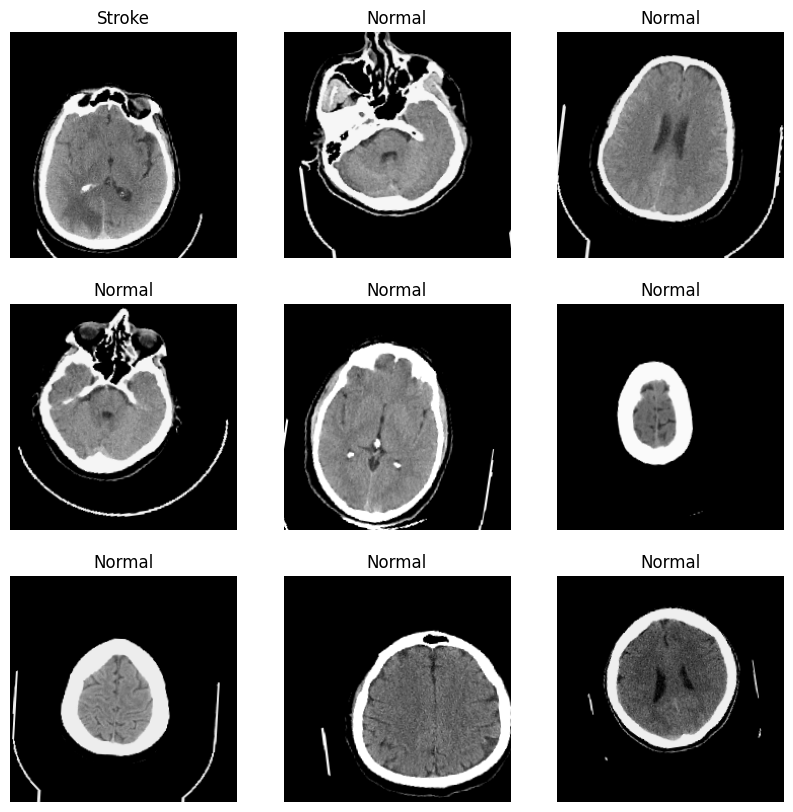

Batch shape: (32, 224, 224, 3)


In [1]:
import os
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

input_folder = r"C:\Dataset\StrokeDataset"
output_folder = r"C:\Dataset\Stroke_Split"

# create train + test only
if not os.path.exists(output_folder):
    splitfolders.fixed(
        input_folder,
        output=output_folder,
        seed=42,
        fixed=(900, 100),   # adjust numbers based on your dataset size
        oversample=False
    )

train_dir = os.path.join(output_folder, "train")
test_dir  = os.path.join(output_folder, "test")

# Softer CT-friendly augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Smoothed class weights (to reduce false positives)
y = train_data.classes.astype(int)
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weight_dict = {
    0: float(cw[0] * 0.7),
    1: float(cw[1] * 0.7)
}

print("Class Weights (Smoothed):", class_weight_dict)

# Visualize
x_vis, y_vis = next(train_data)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_vis[i])
    plt.title("Stroke" if y_vis[i]==1 else "Normal")
    plt.axis("off")
plt.show()

print("Batch shape:", next(train_data)[0].shape)


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=test_data,   # using test as validation
    epochs=5,
    class_weight=class_weight_dict,
    verbose=1
)

model.save("StrokeCNN_224_Improved.h5")


Epoch 1/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.5706 - loss: 0.7990 - val_accuracy: 0.4533 - val_loss: 3.0510
Epoch 2/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.6221 - loss: 0.4628 - val_accuracy: 0.4533 - val_loss: 1.7001
Epoch 3/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.6349 - loss: 0.4477 - val_accuracy: 0.4980 - val_loss: 0.7360
Epoch 4/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.6532 - loss: 0.4351 - val_accuracy: 0.6057 - val_loss: 0.6622
Epoch 5/5
123/123 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.6787 - loss: 0.4231 - val_accuracy: 0.7297 - val_loss: 0.5463


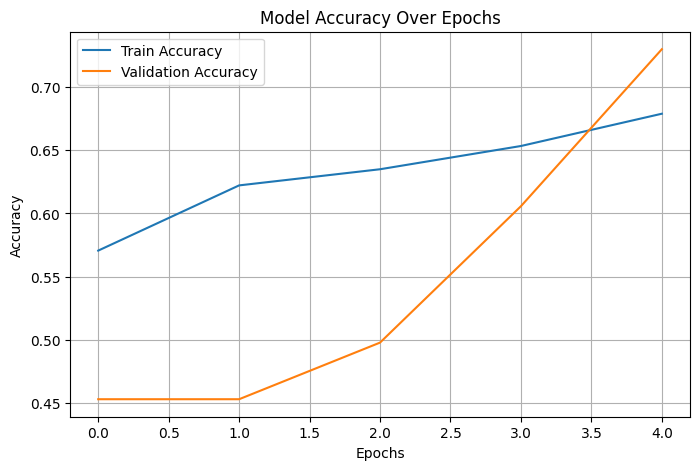

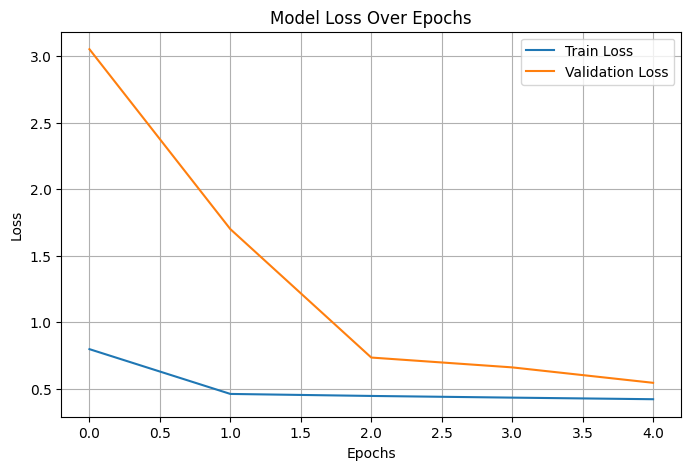

In [4]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 400ms/step 


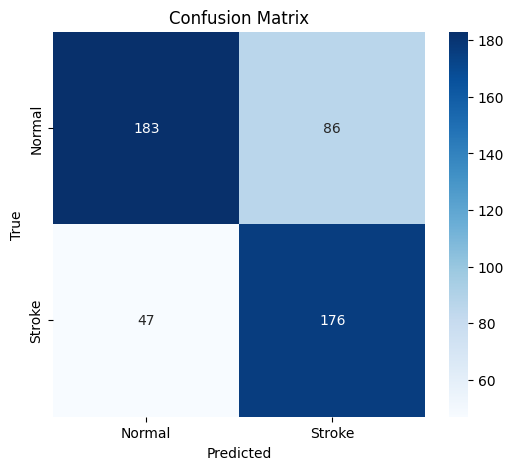


Classification Report:

              precision    recall  f1-score   support

      Normal       0.80      0.68      0.73       269
      Stroke       0.67      0.79      0.73       223

    accuracy                           0.73       492
   macro avg       0.73      0.73      0.73       492
weighted avg       0.74      0.73      0.73       492



In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# True labels
y_true = test_data.classes

# Predicted probabilities
y_pred_probs = model.predict(test_data)  # shape: (num_samples, 1)

# Convert probabilities to class labels
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # 0 or 1

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(test_data.class_indices.keys()),
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

In [6]:
import tensorflow as tf
import numpy as np

img_path = r"C:\dataset\StrokeDataset\Stroke\10033.png"
# Load image as RGB (3 channels)
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224), color_mode="rgb")

# Convert image to array
img_array = tf.keras.preprocessing.image.img_to_array(img)

# Expand dims to create batch of size 1 and normalize
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Get prediction probabilities
prediction = model.predict(img_array)
print(prediction)
# Since binary classification with sigmoid, threshold prediction at 0.5
pred_label = (prediction > 0.5).astype("int32")[0][0]

# Map label index to class name using class_indices from train_data
class_names = list(train_data.class_indices.keys())
pred_class = class_names[pred_label]

print("🧠 Predicted Class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
[[0.65544885]]
🧠 Predicted Class: Stroke
